# CAIRLab Hackathon — Day 2 Extension: Intermediate + Advanced Tracks

Two new tracks unlock today, and you're free to attempt either or both between now and the
submission deadline:

| Track | Goal |
|---|---|
| 🟡 Intermediate | Client data is realistically **skewed** across the five banks — naive FedAvg performs worse under this skew. Fix the **aggregation**. |
| 🔴 Advanced (optional) | Partway through, one bank turns malicious and sends sabotaged updates. **Detect or resist** the attack. |

This notebook is self-contained — it rebuilds the dataset, partitions, model, and FL harness
from scratch, so you don't need yesterday's notebook open. The ideas carry over directly:
same story, same weak baseline, same FedAvg loop as Day 1, extended with what you need for
today's tracks.

**Scoring today:** unlike Day 1, these tracks aren't on a Kaggle leaderboard — a static
prediction file can't capture "how your aggregation holds up under skew" or "how much F1 your
defense recovers under attack." Instead, you'll report your before/after comparison in your
Kaggle Writeup, and export your final model for the organizers to spot-check. See the
Evaluation Rubric on the hackathon page for exact scoring weights.


## 0. Setup

In [1]:

# (pip upgrade removed: pinned preinstalled versions keep the numbers reproducible)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Load and clean the dataset (same as Day 1)


In [2]:

TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

# use the repo's local copy if present (identical files), else download
if os.path.exists("data/KDDTrain+.txt"): TRAIN_URL, TEST_URL = "data/KDDTrain+.txt", "data/KDDTest+.txt"
train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))


features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.


In [3]:

N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())


IID sizes: [22195, 22195, 22195, 22194, 22194]
\nNon-IID sizes: [6272, 10658, 48219, 23239, 22585]
  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)


In [4]:

N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.


In [5]:

X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    '''
    torch.manual_seed(SEED)  # OUR ONE HARNESS CHANGE: every run starts from the same init and batch order,
                             # so before/after differences come from aggregation alone
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.


In [6]:

print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = run_fl(iid_clients, rounds=6)
print("\\nFinal:", baseline_history[-1])


Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}
round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}
round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}
round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}


round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}
round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}
\nFinal: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.


In [7]:

print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = run_fl(noniid_clients, rounds=8)
print("\\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])


Non-IID clients, naive FedAvg (same model, same aggregation as baseline)
round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}
round  2: {'precision': 0.9863, 'recall': 0.5166, 'f1': 0.678}


round  3: {'precision': 0.9436, 'recall': 0.5359, 'f1': 0.6836}


round  4: {'precision': 0.9374, 'recall': 0.5484, 'f1': 0.692}
round  5: {'precision': 0.9371, 'recall': 0.5554, 'f1': 0.6974}
round  6: {'precision': 0.9383, 'recall': 0.5625, 'f1': 0.7034}


round  7: {'precision': 0.9408, 'recall': 0.5662, 'f1': 0.7069}


round  8: {'precision': 0.9524, 'recall': 0.5681, 'f1': 0.7117}
\nIID F1:     0.7641
Non-IID F1: 0.7117


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.


In [8]:
# 🔧 OUR TURN — intermediate track: server momentum (FedAvgM)
def _deltas(local_models, prev):
    ref = get_flat_params(prev)
    return ref, torch.stack([get_flat_params(m) - ref for m in local_models])

def _from_flat(template, flat):
    out = copy.deepcopy(template); set_flat_params(out, flat); return out

def make_fedavgm(beta=0.9, equal=False):
    """Treat the averaged client delta as a pseudo-gradient and apply momentum on the server.
    Skewed clients make the global model zig-zag round to round; momentum keeps the component
    that is consistent across rounds and damps the part that flips."""
    state = {"v": None}
    def agg(local_models, sizes, prev):
        ref, d = _deltas(local_models, prev)
        w = np.ones(len(sizes)) if equal else np.array(sizes, dtype=float)
        w = torch.tensor(w / w.sum(), dtype=torch.float32)
        g = (d * w.unsqueeze(1)).sum(0)
        state["v"] = g if state["v"] is None else beta * state["v"] + g
        return _from_flat(prev, ref + state["v"])
    return agg

def make_balance_weighted(client_dfs, k=3.0):
    """The notebook's first suggestion: down-weight clients whose label mix is far from global."""
    p = np.array([c["binary_label"].mean() for c in client_dfs]); n = np.array([len(c) for c in client_dfs], dtype=float)
    w = n * np.exp(-k * np.abs(p - (p * n).sum() / n.sum()))
    return lambda local_models, sizes, prev: fedavg(local_models, w)

my_agg_fn = make_fedavgm(beta=0.9)
custom_model, custom_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)

# other things we tried (reported honestly in the Writeup)
_, eq_history  = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=make_fedavgm(0.7, equal=True), verbose=False)
_, bal_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=make_balance_weighted(noniid_clients), verbose=False)
_, med_noniid_history = run_fl(noniid_clients, rounds=8, aggregation="median", verbose=False)

print("\nIID reference F1:                 ", baseline_history[-1]["f1"])
print("Naive non-IID F1 (BEFORE):        ", noniid_history[-1]["f1"])
print("FedAvgM beta=0.9 F1 (AFTER, ours):", custom_history[-1]["f1"], f"  (+{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.4f})")
print("FedAvgM 0.7 + equal weights:      ", eq_history[-1]["f1"])
print("Label-balance weighting:          ", bal_history[-1]["f1"], "  (did not help)")
print("Coordinate median (provided):     ", med_noniid_history[-1]["f1"])

round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}
round  2: {'precision': 0.9819, 'recall': 0.5297, 'f1': 0.6881}


round  3: {'precision': 0.9368, 'recall': 0.5531, 'f1': 0.6955}


round  4: {'precision': 0.9327, 'recall': 0.5839, 'f1': 0.7182}


round  5: {'precision': 0.9287, 'recall': 0.627, 'f1': 0.7486}
round  6: {'precision': 0.9025, 'recall': 0.6388, 'f1': 0.7481}


round  7: {'precision': 0.8827, 'recall': 0.6532, 'f1': 0.7508}


round  8: {'precision': 0.9629, 'recall': 0.5992, 'f1': 0.7387}



IID reference F1:                  0.7641
Naive non-IID F1 (BEFORE):         0.7117
FedAvgM beta=0.9 F1 (AFTER, ours): 0.7387   (+0.0270)
FedAvgM 0.7 + equal weights:       0.7368
Label-balance weighting:           0.7035   (did not help)
Coordinate median (provided):      0.7489


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.


In [9]:

print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])


Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade
round  1: {'precision': 1.0, 'recall': 0.1038, 'f1': 0.1881}
round  2: {'precision': 0.9959, 'recall': 0.1128, 'f1': 0.2026}
round  3: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


round  4: {'precision': 0.8421, 'recall': 0.0087, 'f1': 0.0173}
round  5: {'precision': 0.8779, 'recall': 0.0118, 'f1': 0.0232}
round  6: {'precision': 0.854, 'recall': 0.0337, 'f1': 0.0649}
round  7: {'precision': 0.9868, 'recall': 0.2497, 'f1': 0.3986}


round  8: {'precision': 0.0794, 'recall': 0.0376, 'f1': 0.0511}
\nClean non-IID F1:   0.7117
Under attack F1:     0.0511


In [10]:

print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])


Same attack, but aggregating with the coordinate-median baseline defense
round  1: {'precision': 1.0, 'recall': 0.082, 'f1': 0.1515}
round  2: {'precision': 0.999, 'recall': 0.1514, 'f1': 0.263}
round  3: {'precision': 0.9991, 'recall': 0.4551, 'f1': 0.6253}


round  4: {'precision': 0.9953, 'recall': 0.4952, 'f1': 0.6614}
round  5: {'precision': 0.9884, 'recall': 0.5102, 'f1': 0.673}
round  6: {'precision': 0.988, 'recall': 0.5186, 'f1': 0.6802}
round  7: {'precision': 0.9878, 'recall': 0.5227, 'f1': 0.6837}


round  8: {'precision': 0.9875, 'recall': 0.525, 'f1': 0.6855}
\nUnder attack (naive FedAvg):  0.0511
Under attack (median defense): 0.6855


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.


In [11]:
# 🔧 OUR TURN — advanced track: flag + drop + clip, with a detection log
DETECTION_LOG = []   # one row per round: which clients were flagged, and every client's update norm

def make_robust(norm_mult=3.0, log=None):
    """1) FLAG a client if its update norm is > norm_mult x the median norm (catches scaling),
          or its cosine similarity to the coordinate-median update is negative (catches label flipping).
       2) DROP flagged clients this round.
       3) CLIP survivors to the median norm (bounds anything that slipped through).
       4) Size-weighted average of the rest."""
    state = {"r": 0}
    def agg(local_models, sizes, prev):
        state["r"] += 1
        ref, d = _deltas(local_models, prev)
        norms = d.norm(dim=1); med_norm = norms.median()
        med_dir = d.median(dim=0).values
        cos = torch.nn.functional.cosine_similarity(d, med_dir.unsqueeze(0), dim=1)
        bad = (norms > norm_mult * med_norm) | (cos < 0)
        if bad.all(): bad[:] = False
        if log is not None:
            log.append({"round": state["r"], "flagged": [i for i, b in enumerate(bad.tolist()) if b],
                        "norms": [round(x, 2) for x in norms.tolist()], "cosine": [round(x, 2) for x in cos.tolist()]})
        d = d * torch.clamp(med_norm / (norms + 1e-12), max=1.0).unsqueeze(1)
        w = torch.tensor(np.array(sizes, dtype=float), dtype=torch.float32) * (~bad).float()
        return _from_flat(prev, ref + (d * (w / w.sum()).unsqueeze(1)).sum(0))
    return agg

my_defense_fn = make_robust(log=DETECTION_LOG)
my_defense_model, my_defense_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="custom", agg_fn=my_defense_fn,
)
print("\nNaive under attack (BEFORE):", attacked_history[-1]["f1"])
print("Median defense (provided):  ", defended_history[-1]["f1"])
print("Our defense (AFTER):        ", my_defense_history[-1]["f1"], f"  (recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.4f})")
print("\nDetection log — the true attacker is client 1:")
for row in DETECTION_LOG: print("  ", row)

round  1: {'precision': 0.9897, 'recall': 0.1729, 'f1': 0.2944}
round  2: {'precision': 0.9838, 'recall': 0.2126, 'f1': 0.3496}
round  3: {'precision': 0.9891, 'recall': 0.5031, 'f1': 0.6669}


round  4: {'precision': 0.9835, 'recall': 0.5251, 'f1': 0.6846}


round  5: {'precision': 0.9572, 'recall': 0.5309, 'f1': 0.683}
round  6: {'precision': 0.9676, 'recall': 0.5355, 'f1': 0.6894}
round  7: {'precision': 0.9779, 'recall': 0.5387, 'f1': 0.6947}


round  8: {'precision': 0.982, 'recall': 0.54, 'f1': 0.6968}

Naive under attack (BEFORE): 0.0511
Median defense (provided):   0.6855
Our defense (AFTER):         0.6968   (recovered +0.6457)

Detection log — the true attacker is client 1:
   {'round': 1, 'flagged': [0, 1], 'norms': [0.55, 10.4, 1.69, 1.19, 1.12], 'cosine': [-0.18, 0.07, 0.64, 0.96, 0.96]}
   {'round': 2, 'flagged': [0, 1], 'norms': [0.69, 14.27, 1.03, 0.57, 0.52], 'cosine': [-0.02, -0.46, 0.54, 0.92, 0.85]}
   {'round': 3, 'flagged': [1], 'norms': [0.71, 18.33, 0.76, 0.35, 0.35], 'cosine': [0.05, -0.33, 0.35, 0.69, 0.67]}
   {'round': 4, 'flagged': [1], 'norms': [0.68, 21.46, 0.73, 0.32, 0.32], 'cosine': [0.3, 0.06, 0.64, 0.48, 0.37]}
   {'round': 5, 'flagged': [1], 'norms': [0.62, 23.56, 0.49, 0.29, 0.28], 'cosine': [0.19, 0.15, 0.4, 0.19, 0.25]}
   {'round': 6, 'flagged': [1], 'norms': [0.59, 25.12, 0.38, 0.24, 0.27], 'cosine': [0.11, 0.23, 0.27, 0.14, 0.22]}
   {'round': 7, 'flagged': [1], 'norms': [0.58, 26.2, 0.3

### Stress tests

In [12]:
# Stress tests: stronger scaling, two attackers, and an attacker that does NOT scale (label flip only)
scenarios = {
    "1 attacker, scale 15": dict(malicious_clients=[1], attack="scale", scale_factor=15.0),
    "1 attacker, scale 50": dict(malicious_clients=[1], attack="scale", scale_factor=50.0),
    "2 attackers [1,3], scale 15": dict(malicious_clients=[1, 3], attack="scale", scale_factor=15.0),
    "1 attacker, label flip only": dict(malicious_clients=[1], attack="label_flip"),
}
print(f"{'scenario':<30}{'naive FedAvg':>14}{'median':>10}{'ours':>10}   flagged per round (ours)")
for name, kw in scenarios.items():
    log = []
    f_naive = run_fl(noniid_clients, rounds=8, verbose=False, **kw)[1][-1]["f1"]
    f_med   = run_fl(noniid_clients, rounds=8, verbose=False, aggregation="median", **kw)[1][-1]["f1"]
    f_ours  = run_fl(noniid_clients, rounds=8, verbose=False, aggregation="custom", agg_fn=make_robust(log=log), **kw)[1][-1]["f1"]
    print(f"{name:<30}{f_naive:>14}{f_med:>10}{f_ours:>10}   {[r['flagged'] for r in log]}")

scenario                        naive FedAvg    median      ours   flagged per round (ours)


1 attacker, scale 15                  0.0511    0.6855    0.6968   [[0, 1], [0, 1], [1], [1], [1], [1], [1], [1]]


1 attacker, scale 50                  0.6215    0.6861    0.6968   [[0, 1], [0, 1], [1], [1], [1], [1], [1], [1]]


2 attackers [1,3], scale 15           0.0017    0.7083    0.7132   [[1, 3], [1, 3, 4], [1, 3, 4], [1, 3, 4], [1, 3, 4], [1, 3, 4], [1, 3], [1, 3, 4]]


1 attacker, label flip only            0.685    0.6773    0.6926   [[0], [1], [1], [1], [1], [1], [1], [1]]


### Cover chart

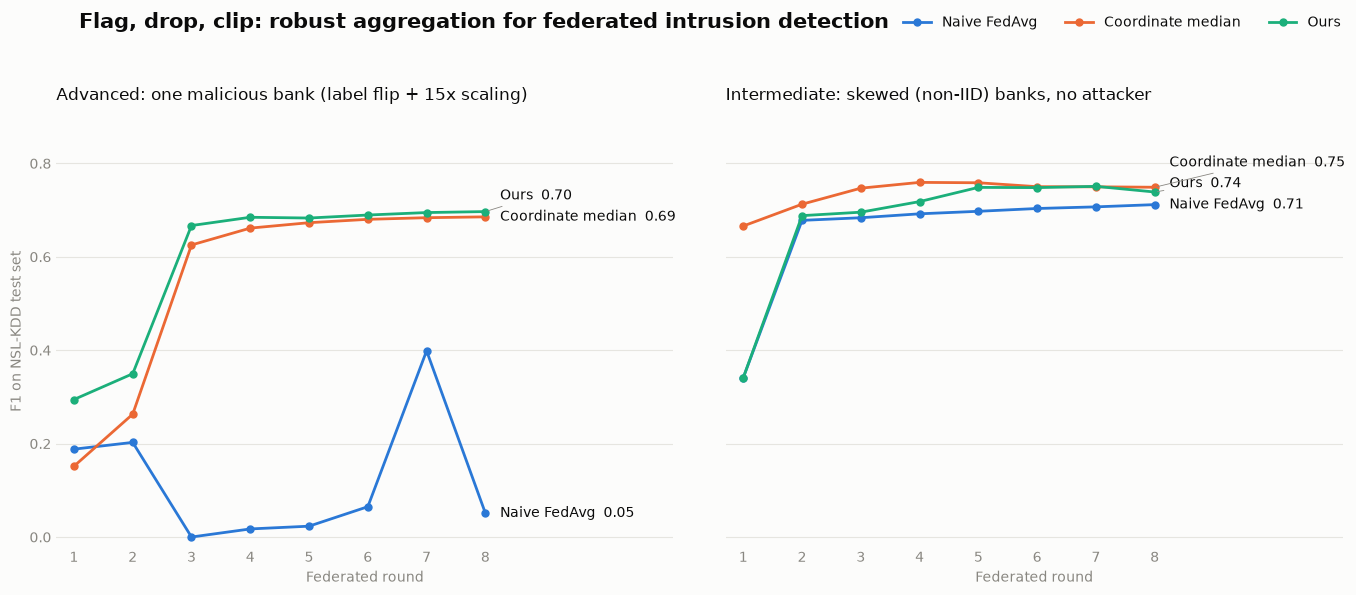

In [13]:
# Cover image: F1 by round, before vs after, both tracks
import matplotlib.pyplot as plt
INK, MUTED, SURF = "#0b0b0b", "#898781", "#fcfcfb"
C = {"Naive FedAvg": "#2a78d6", "Coordinate median": "#eb6834", "Ours": "#1baf7a"}
f1s = lambda h: [x["f1"] for x in h]
panels = [
    ("Advanced: one malicious bank (label flip + 15x scaling)",
     {"Naive FedAvg": f1s(attacked_history), "Coordinate median": f1s(defended_history), "Ours": f1s(my_defense_history)}),
    ("Intermediate: skewed (non-IID) banks, no attacker",
     {"Naive FedAvg": f1s(noniid_history), "Coordinate median": f1s(med_noniid_history), "Ours": f1s(custom_history)}),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor=SURF)
for ax, (title, series) in zip(axes, panels):
    ax.set_facecolor(SURF)
    ends = sorted(((v[-1], k) for k, v in series.items()))
    for k, v in series.items():
        ax.plot(range(1, 9), v, color=C[k], lw=2, marker="o", ms=5, label=k, zorder=3)
    last_y = -1
    for y, k in ends:  # direct labels at line ends, nudged apart so they never collide
        ly = max(y, last_y + 0.045); last_y = ly
        ax.annotate(f"{k}  {y:.2f}", (8, y), xytext=(8.25, ly), color=INK, fontsize=10, va="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6) if abs(ly - y) > 0.01 else None)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=12)
    ax.set_xlabel("Federated round", color=MUTED); ax.set_xlim(0.7, 11.2); ax.set_xticks(range(1, 9)); ax.set_ylim(-0.02, 0.9)
    ax.grid(axis="y", color="#e6e5e0", lw=0.8); ax.tick_params(colors=MUTED, length=0)
    for s in ax.spines.values(): s.set_visible(False)
axes[0].set_ylabel("F1 on NSL-KDD test set", color=MUTED)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper right", bbox_to_anchor=(0.97, 0.995), ncol=3, fontsize=10, labelcolor=INK)
fig.suptitle("Flag, drop, clip: robust aggregation for federated intrusion detection", color=INK, fontsize=15, x=0.06, ha="left", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94)); fig.savefig("cover.png", dpi=150, facecolor=SURF); plt.show()

---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.


In [14]:

TEAM_NAME = "ZeroTrustAI"
TRACK = "advanced"  # "intermediate" or "advanced"
FINAL_MODEL = my_defense_model  # <- point this at whichever model you want submitted

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

print(json.dumps(submission, indent=2))
print("\\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).")


{
  "team_name": "ZeroTrustAI",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.982,
    "recall": 0.54,
    "f1": 0.6968
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}
\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).


/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.
